In [1]:
import pandas as pd

df = pd.read_csv("AI_Salary_Prediction_100Rows.csv") # Load Dataset

print(df.head()) # Show First 5 Rows

print(df.shape) # Dataset Shape

   EmployeeID  Age  YearsExperience  Education  Salary
0           1   41                3  Bachelors   61506
1           2   28                7  Bachelors   74679
2           3   42               17  Bachelors  122674
3           4   34                1  Bachelors   50535
4           5   27                7        PhD  122863
(100, 5)


count       100.000000
mean     109904.220000
std       30275.427459
min       49525.000000
25%       85624.500000
50%      109612.000000
75%      129404.250000
max      166612.000000
Name: Salary, dtype: float64


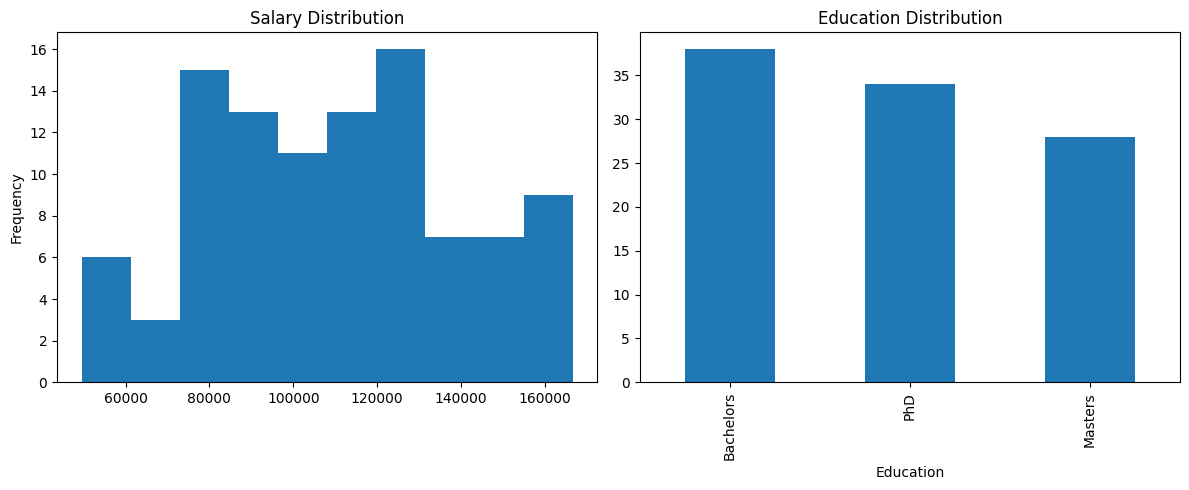

In [2]:
import matplotlib.pyplot as plt

print(df['Salary'].describe()) # Salary Distribution

plt.figure(figsize=(12,5)) # Create Charts

plt.subplot(1,2,1) # Salary Histogram

df['Salary'].plot(
    kind='hist',
    bins=10
)

plt.title("Salary Distribution")

plt.subplot(1,2,2) # Education Count Chart

df['Education'].value_counts().plot(
    kind='bar'
)

plt.title("Education Distribution")

plt.tight_layout() # Show Charts
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

le = LabelEncoder() # Convert Education text into numbers

df['Education'] = le.fit_transform(df['Education'])

X = df[['Age', 'YearsExperience', 'Education']] # Features and Target

y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split( # Split Data
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeRegressor() # Create AI Model

model.fit(X_train, y_train) # Train Model

y_pred = model.predict(X_test) # Prediction

error = mean_absolute_error(y_test, y_pred) # Error Checking

print("Mean Absolute Error:", error)

Mean Absolute Error: 6119.65


In [4]:
new_employee = pd.DataFrame( # New Employee Data
    [[25, 3, 0]],
    columns=['Age', 'YearsExperience', 'Education']
)

prediction = model.predict(new_employee) # Predict Salary

print("Predicted Salary:", prediction[0])

Predicted Salary: 51504.0


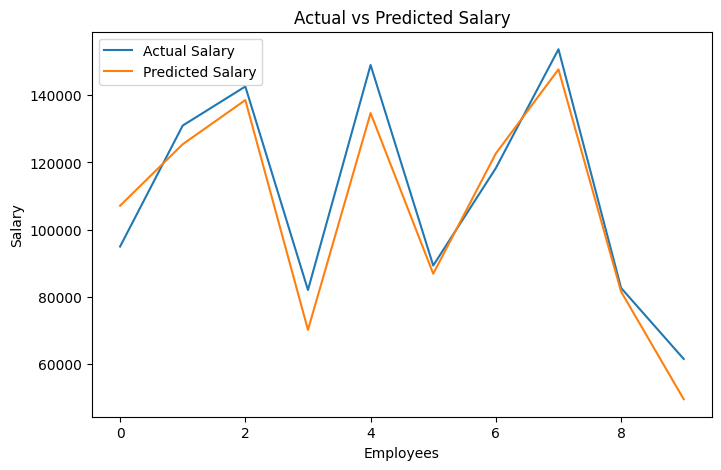

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5)) # Compare Actual vs Predicted

plt.plot(y_test.values[:10], label='Actual Salary')
plt.plot(y_pred[:10], label='Predicted Salary')

plt.title("Actual vs Predicted Salary")
plt.xlabel("Employees")
plt.ylabel("Salary")

plt.legend()

plt.show()